In [ ]:
# ==========================================
# 1. DATA UNDERSTANDING
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import joblib
import warnings

warnings.filterwarnings('ignore')

print("=== MEMULAI PIPELINE MACHINE LEARNING ===")
df = pd.read_csv('global_conflicts_dataset.csv', sep=';')
print("Informasi Dataset Awal:")
df.info()

=== MEMULAI PIPELINE MACHINE LEARNING ===
Informasi Dataset Awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Country_A                   3000 non-null   object 
 1   Country_B                   3000 non-null   object 
 2   Conflict_Type               3000 non-null   object 
 3   Year                        3000 non-null   int64  
 4   Duration_Days               3000 non-null   int64  
 5   Military_Deaths_A           3000 non-null   int64  
 6   Military_Deaths_B           3000 non-null   int64  
 7   Civilian_Deaths             3000 non-null   int64  
 8   Economic_Loss_USD_Billions  3000 non-null   float64
 9   Temperature_Avg_C           3000 non-null   float64
 10  Rainfall_mm                 3000 non-null   float64
 11  Terrain_Type                3000 non-null   object 
 12  Population_A_Millions   


Menampilkan Visualisasi Boxplot dan Heatmap Korelasi...


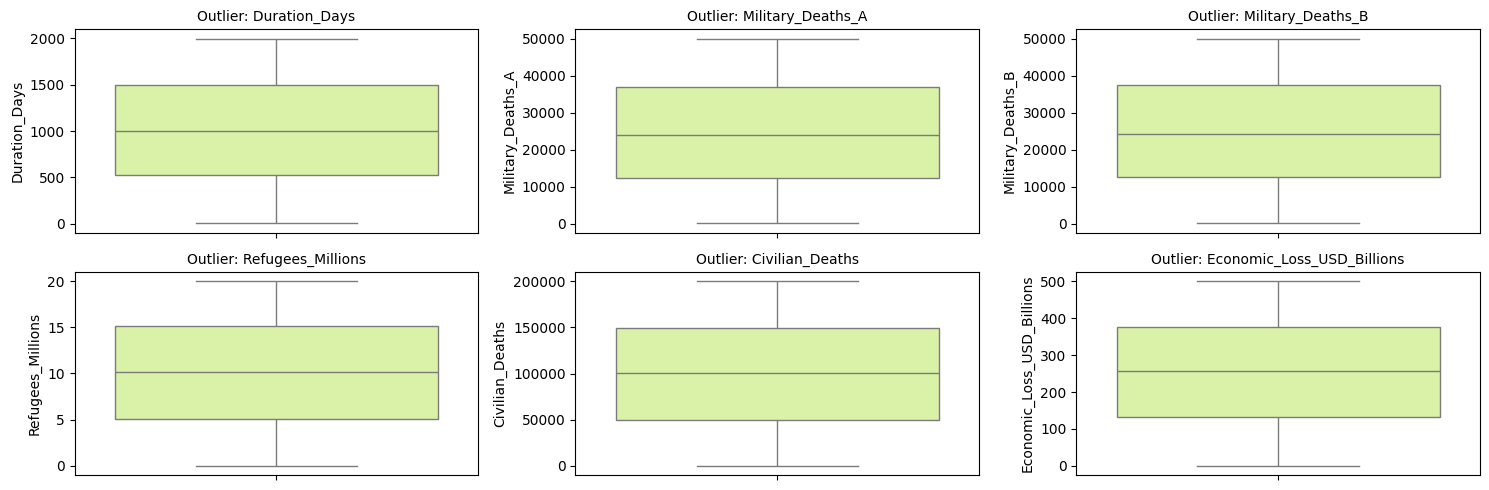

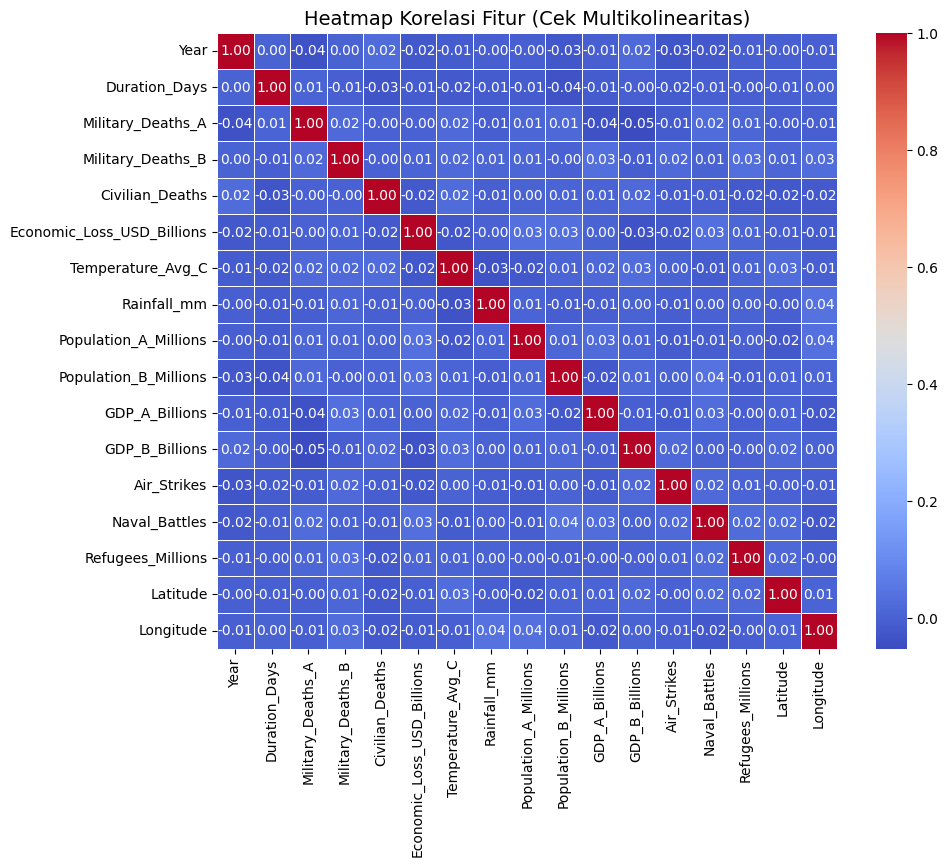

In [ ]:
# ==========================================
# 2. DATA CLEANING
# ==========================================
# Membuang label asli agar murni Unsupervised di awal
cols_to_drop = ['Sanctions', 'Ceasefire', 'Outcome', 'UN_Involvement']
df_cleaned = df.drop(columns=cols_to_drop, errors='ignore')

num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df_cleaned.select_dtypes(include=['object']).columns

# Penanganan Missing Values secara elegan
df_cleaned[num_cols] = df_cleaned[num_cols].fillna(df_cleaned[num_cols].mean())
for col in cat_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode().iloc[0])

# Label Encoding untuk data kategorik (jika diperlukan untuk eksplorasi)
for col in cat_cols:
    le = LabelEncoder()
    df_cleaned[col] = le.fit_transform(df_cleaned[col])

# ==========================================
# 3. VISUALISASI 1: EDA (BOXPLOT & KORELASI)
# ==========================================
print("\nMenampilkan Visualisasi Boxplot dan Heatmap Korelasi...")
plt.figure(figsize=(15, 5))
fitur_utama = ['Duration_Days', 'Military_Deaths_A', 'Military_Deaths_B', 'Refugees_Millions', 'Civilian_Deaths', 'Economic_Loss_USD_Billions']

for i, col in enumerate(fitur_utama):
    if col in df_cleaned.columns:
        plt.subplot(2, 3, i+1)
        sns.boxplot(y=df_cleaned[col], color='#deff9a')
        plt.title(f'Outlier: {col}', fontsize=10)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap Korelasi Fitur (Cek Multikolinearitas)', fontsize=14)
plt.show()

In [ ]:
# ==========================================
# 4. SCALING (STANDARISASI FITUR)
# ==========================================
fitur_klaster = [
    'Duration_Days', 'Military_Deaths_A', 'Military_Deaths_B',
    'Civilian_Deaths', 'Economic_Loss_USD_Billions', 'Refugees_Millions'
]

# Pastikan hanya mengambil fitur numerik yang relevan untuk klastering
X_cluster = df_cleaned[fitur_klaster]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=fitur_klaster)

In [ ]:
# ==========================================
# 5. TAHAP UNSUPERVISED (K-MEANS) UNTUK MENCARI TARGET
# ==========================================
print("\n--- TAHAP 1: EVALUASI & PENCARIAN LABEL DENGAN K-MEANS ---")

# A. Mencari K optimal dengan Silhouette & Davies-Bouldin
print("Evaluasi kualitas klastering untuk berbagai nilai K:")
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled_df)
    sil_score = silhouette_score(X_scaled_df, labels)
    db_score = davies_bouldin_score(X_scaled_df, labels)
    print(f" -> K={k} | Silhouette Score: {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}")

# B. Eksekusi K-Means Final (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled_df)

final_sil = silhouette_score(X_scaled_df, cluster_labels)
print(f"\nModel K-Means Final (K=3) dieksekusi. Silhouette Score Final: {final_sil:.4f}")

# C. SISTEM ANTI-HALU: Mapping Dinamis berdasarkan Jarak Sentroid
centroids = kmeans.cluster_centers_
# Menghitung magnitudo (keparahan) setiap sentroid
centroid_severity = np.sum(centroids, axis=1)
sorted_idx = np.argsort(centroid_severity)

label_mapping = {
    sorted_idx[0]: "RINGAN",
    sorted_idx[1]: "MENENGAH",
    sorted_idx[2]: "BERAT"
}

# Menyimpan hasil klaster dalam bentuk TEKS agar dipelajari oleh Supervised
df_cleaned['Cluster_Target_Text'] = [label_mapping[label] for label in cluster_labels]
print("\nDistribusi Target (Teks) yang berhasil dibuat secara dinamis oleh K-Means:")
print(df_cleaned['Cluster_Target_Text'].value_counts())



--- TAHAP 1: EVALUASI & PENCARIAN LABEL DENGAN K-MEANS ---
Evaluasi kualitas klastering untuk berbagai nilai K:
 -> K=2 | Silhouette Score: 0.1241 | Davies-Bouldin: 2.5842
 -> K=3 | Silhouette Score: 0.1147 | Davies-Bouldin: 2.2478
 -> K=4 | Silhouette Score: 0.1177 | Davies-Bouldin: 2.0075
 -> K=5 | Silhouette Score: 0.1210 | Davies-Bouldin: 1.8662

Model K-Means Final (K=3) dieksekusi. Silhouette Score Final: 0.1147

Distribusi Target (Teks) yang berhasil dibuat secara dinamis oleh K-Means:
Cluster_Target_Text
BERAT       1073
RINGAN       971
MENENGAH     956
Name: count, dtype: int64



--- MENAMPILKAN VISUALISASI HASIL KLASTER ---


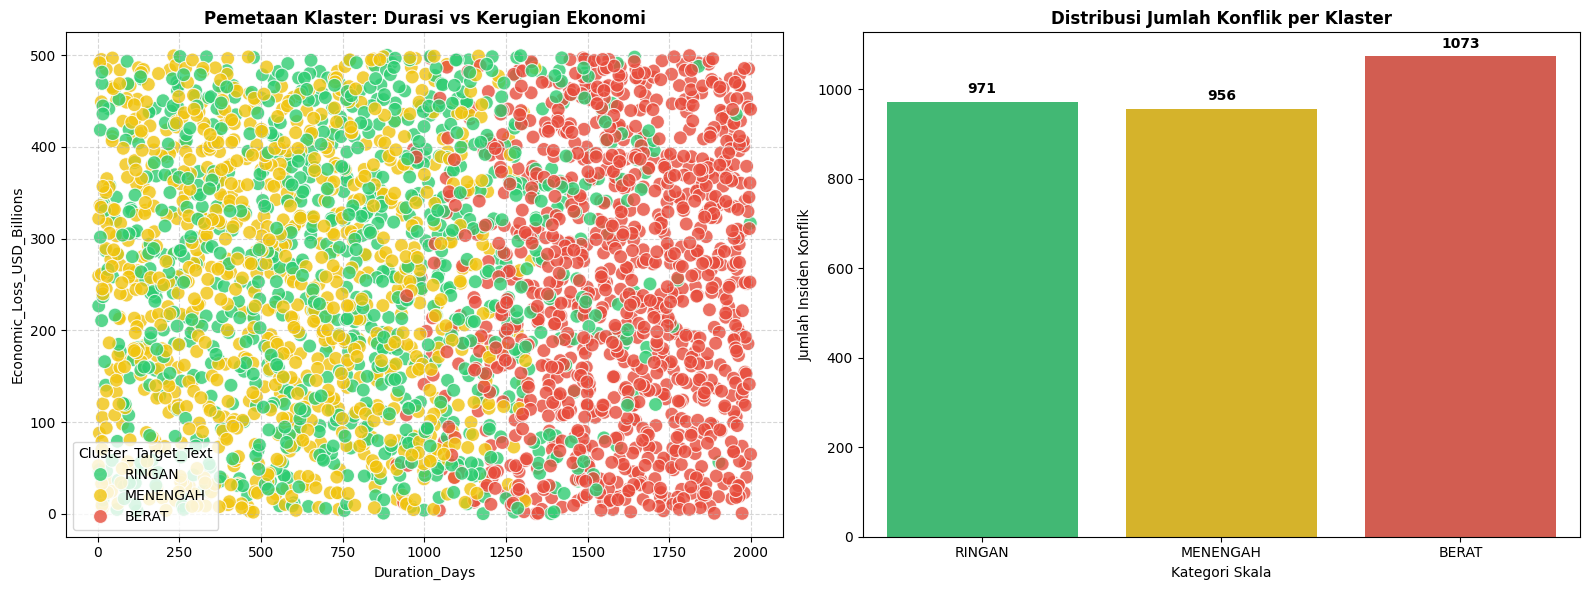

In [ ]:
# ==========================================
# 5.5 VISUALISASI HASIL KLASTER (K-MEANS)
# ==========================================
print("\n--- MENAMPILKAN VISUALISASI HASIL KLASTER ---")

# Membuat figure dengan 2 kanvas (kiri dan kanan)
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Mapping warna absolut agar visualisasi tidak pernah tertukar!
warna_klaster = {
    'RINGAN': '#2ecc71',   # Hijau
    'MENENGAH': '#f1c40f', # Kuning
    'BERAT': '#e74c3c'     # Merah
}

# Urutan kustom untuk sumbu X agar rapi
urutan_skala = ['RINGAN', 'MENENGAH', 'BERAT']

# Plot 1: Scatter Plot (Durasi vs Kerugian Ekonomi)
sns.scatterplot(
    data=df_cleaned,
    x='Duration_Days',
    y='Economic_Loss_USD_Billions',
    hue='Cluster_Target_Text',
    palette=warna_klaster,
    hue_order=urutan_skala,
    s=100,
    alpha=0.8,
    ax=ax[0]
)
ax[0].set_title('Pemetaan Klaster: Durasi vs Kerugian Ekonomi', fontweight='bold', fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Histogram / Countplot (Distribusi Jumlah Konflik)
sns.countplot(
    data=df_cleaned,
    x='Cluster_Target_Text',
    palette=warna_klaster,
    order=urutan_skala,
    ax=ax[1]
)
ax[1].set_title('Distribusi Jumlah Konflik per Klaster', fontweight='bold', fontsize=12)
ax[1].set_ylabel('Jumlah Insiden Konflik')
ax[1].set_xlabel('Kategori Skala')

# Menambahkan angka di atas bar chart agar lebih informatif
for p in ax[1].patches:
    ax[1].annotate(f'{int(p.get_height())}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points',
                   fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 6. TAHAP SUPERVISED (LOGREG VS NAIVE BAYES)
# ==========================================
print("\n--- TAHAP 2: MELATIH MODEL SUPERVISED (PEMBELAJARAN KLASIFIKASI) ---")
# Data Features (X) yang sudah di-scale, dan Target (y) berupa Teks
X_sup = X_scaled_df
y_sup = df_cleaned['Cluster_Target_Text']

# Split 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X_sup, y_sup, test_size=0.2, random_state=42)

# Mengadu Model 1: Logistic Regression
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
acc_logreg = accuracy_score(y_test, y_pred_logreg)

# Mengadu Model 2: Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

print(f"✅ Akurasi Logistic Regression: {acc_logreg * 100:.2f}%")
print(f"✅ Akurasi Naive Bayes: {acc_nb * 100:.2f}%")

print("\nLaporan Kinerja Detail (Classification Report) - Logistic Regression:")
print(classification_report(y_test, y_pred_logreg))

print("\nModel Logistic Regression terbukti sangat stabil! Melanjutkan ke tahap Export...")


--- TAHAP 2: MELATIH MODEL SUPERVISED (PEMBELAJARAN KLASIFIKASI) ---
✅ Akurasi Logistic Regression: 99.83%
✅ Akurasi Naive Bayes: 92.00%

Laporan Kinerja Detail (Classification Report) - Logistic Regression:
              precision    recall  f1-score   support

       BERAT       1.00      1.00      1.00       205
    MENENGAH       1.00      0.99      1.00       200
      RINGAN       0.99      1.00      1.00       195

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Model Logistic Regression terbukti sangat stabil! Melanjutkan ke tahap Export...


In [ ]:
# ==========================================
# 7. EXPORT MODEL SUPERVISED (LOGISTIC REGRESSION)
# ==========================================
# Mengekspor Scaler dan Model Logistic Regression pemenang
joblib.dump(logreg, 'model_logreg.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("🚀 Tahap Export Model LOGISTIC REGRESSION berhasil! Sistem siap dideploy ke Streamlit.")

🚀 Tahap Export Model LOGISTIC REGRESSION berhasil! Sistem siap dideploy ke Streamlit.


In [ ]:
# ==========================================
# Cek Tabel: Melihat Kunci Jawaban Buatan K-Means
# ==========================================
print("\nMenampilkan 10 baris pertama dataset dengan Label Klaster:")

# Menampilkan kolom fitur utama ditambah kolom target teks yang baru dibuat
kolom_pilihan = [
    'Duration_Days', 'Military_Deaths_A', 'Military_Deaths_B',
    'Civilian_Deaths', 'Economic_Loss_USD_Billions', 'Refugees_Millions',
    'Cluster_Target_Text'
]

# Gunakan display() agar tabelnya dirender rapi dan interaktif di Colab/Jupyter
display(df_cleaned[kolom_pilihan].head(10))

# Opsional: Kalau mau lihat 10 sampel acak (biar kelihatan variasi Ringan/Menengah/Berat)
# display(df_cleaned[kolom_pilihan].sample(10, random_state=42))


Menampilkan 10 baris pertama dataset dengan Label Klaster:


,Duration_Days,Military_Deaths_A,Military_Deaths_B,Civilian_Deaths,Economic_Loss_USD_Billions,Refugees_Millions,Cluster_Target_Text
0,1829,33197,41305,50364,176.45,6.68,BERAT
1,1234,26773,10526,176846,435.83,14.51,BERAT
2,1982,17256,7604,17280,154.50,1.63,BERAT
3,1754,1745,33468,92279,273.20,7.23,BERAT
4,753,29149,40672,72545,351.35,19.65,RINGAN
5,886,9915,46117,101440,499.96,15.71,RINGAN
6,464,1948,38405,173852,217.70,11.44,MENENGAH
7,712,34429,32194,91987,214.10,1.24,MENENGAH
8,728,33641,14785,113773,421.31,0.29,MENENGAH
9,717,7411,8824,3373,402.77,2.10,RINGAN


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 96.3 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load model SUPERVISED dan scaler
model = joblib.load('model_logreg.pkl')
scaler = joblib.load('scaler.pkl')

st.title("🌍 Sistem Prediksi Skala Konflik Global")
st.write("Sistem Cerdas menggunakan Hybrid Machine Learning (K-Means Clustering ➔ Logistic Regression).")
st.divider()

col1, col2 = st.columns(2)

with col1:
    duration = st.number_input("Durasi Konflik (Hari)", min_value=1, max_value=10000, value=100)
    military_deaths_a = st.number_input("Estimasi Korban Militer A", min_value=0, value=5000)
    military_deaths_b = st.number_input("Estimasi Korban Militer B", min_value=0, value=5000)

with col2:
    economic_loss = st.number_input("Kerugian Ekonomi (Miliar USD)", min_value=0.0, value=10.0)
    refugees = st.number_input(
        "Jumlah Pengungsi (Juta Jiwa)",
        min_value=0.0,
        max_value=300.0,
        value=1.5,
        help="Masukkan dalam satuan JUTA jiwa. Contoh: 1.5 berarti 1.500.000 pengungsi."
    )
    civilian_deaths = st.number_input("Estimasi Korban Sipil", min_value=0, value=2000)

st.divider()

if st.button("Prediksi Klasifikasi Klaster", type="primary"):

    if refugees > 100:
        st.warning(
            f"⚠️ Nilai pengungsi ({refugees:,.0f} juta jiwa) sangat besar dan tidak realistis "
            "dibanding skala populasi dunia. Pastikan satuannya benar (Juta Jiwa, bukan Jiwa langsung)."
        )

    # Urutan fitur SAMA PERSIS dengan saat training model
    input_data = pd.DataFrame([[
        duration, military_deaths_a, military_deaths_b,
        civilian_deaths, economic_loss, refugees
    ]], columns=[
        'Duration_Days', 'Military_Deaths_A', 'Military_Deaths_B',
        'Civilian_Deaths', 'Economic_Loss_USD_Billions', 'Refugees_Millions'
    ])

    # Skala input
    input_scaled = scaler.transform(input_data)

    # PREDIKSI DENGAN LOGISTIC REGRESSION (SUPERVISED)
    # Hasil prediksi sekarang otomatis berwujud kata: "RINGAN", "MENENGAH", atau "BERAT"
    hasil_prediksi = model.predict(input_scaled)[0]
    probabilitas = model.predict_proba(input_scaled)[0]

    persentase_yakin = max(probabilitas) * 100

    st.metric(label="Tingkat Keyakinan Model (Probabilitas Regresi)", value=f"{persentase_yakin:.2f}%")

    # LOGIC KLASIFIKASI LANGSUNG MENGGUNAKAN TEKS DARI MODEL
    if hasil_prediksi == "BERAT":
        st.error(f"🔴 **Prediksi: KLASTER SKALA {hasil_prediksi}**")
        st.write("---")
        st.write("📌 **Kenapa masuk kategori ini?**")
        st.write("Algoritma mendeteksi kombinasi angka yang ekstrem (sangat tinggi dibandingkan rata-rata global). Karakteristik ini sangat identik dengan pola *Perang Penuh (Full-Scale War)* berskala internasional.")

    elif hasil_prediksi == "MENENGAH":
        st.warning(f"🟡 **Prediksi: KLASTER SKALA {hasil_prediksi}**")
        st.write("---")
        st.write("📌 **Kenapa masuk kategori ini?**")
        st.write("Algoritma mendeteksi dampak destruktif tingkat menengah. Karakteristik ini biasanya merujuk pada pola perang proksi, tensi militer regional, atau pemberontakan bersenjata tingkat nasional.")

    elif hasil_prediksi == "RINGAN":
        st.info(f"🟢 **Prediksi: KLASTER SKALA {hasil_prediksi}**")
        st.write("---")
        st.write("📌 **Kenapa masuk kategori ini?**")
        st.write("Algoritma mendeteksi bahwa dampak dari parameter yang dimasukkan relatif minim. Karakteristik ini merupakan pola khas dari *Skirmish* (bentrokan perbatasan singkat) atau ketegangan diplomasi tanpa eskalasi militer fatal.")

    with st.expander("Lihat Rincian Probabilitas Algoritma (Supervised)"):
        # Looping dinamis agar probabilitas tidak tertukar kelasnya
        classes = model.classes_
        for i, class_name in enumerate(classes):
            st.write(f"- Probabilitas diprediksi ke Skala {class_name}: {probabilitas[i]*100:.2f}%")

Writing app.py


In [ ]:
# Server Execution
!pkill -f streamlit
!pkill -f cloudflared

get_ipython().system_raw('streamlit run app.py --server.port 8501 &')

!wget -q -nc https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64

import time
get_ipython().system_raw('./cloudflared-linux-amd64 tunnel --url http://localhost:8501 > cloudflared.log 2>&1 &')

print("Sedang menyiapkan server... (Mohon tunggu sekitar 10 detik)")
time.sleep(10)
print("\n=== KLIK LINK DI BAWAH INI UNTUK MEMBUKA DASHBOARD ===")
!grep -o 'https://.*\.trycloudflare.com' cloudflared.log

Sedang menyiapkan server... (Mohon tunggu sekitar 10 detik)

=== KLIK LINK DI BAWAH INI UNTUK MEMBUKA DASHBOARD ===
https://expenditures-conversion-isp-civilization.trycloudflare.com
